<a href="https://colab.research.google.com/github/dantae74/aice/blob/main/ref/01_%EA%BD%83_%EC%9D%B4%EB%AF%B8%EC%A7%80_%EB%B6%84%EB%A5%98%ED%95%98%EA%B8%B0_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 이미지 실습
# 꽃 이미지 데이터를 가지고 이미지 모델을 만들고 분류

### 학습목차

#### A. 라벨정보 포함한 이미지 데이터셋 만들기
1. 필요한 라이브러리 임포트
2. 이미지 파일 가져오기
3. os.listdir과 PIL.Image 이용하여 이미지 읽기
4. 이미지 라벨링 포함해서 Class별 이미지 리스트 만들기
5. Train/Test 데이터셋 만들기

#### B. Build Model
1. Build Model
2. Callback
3. 모델 학습
4. 성능 그래프
5. Predict

#### C. image_dataset_from_directory 이용하여 데이터셋 만들기
1. 필요한 라이브러리 임포트
2. 이미지 파일 가져오기
3. 이미지 파일 하나 읽어 이미지 보기
4. Data Preprocess : image_dataset_from_directory 이용하여 한번에 처리

#### D. 모델링
1. Build Model : Functional API
2. Callback
3. 모델 학습
4. 성능 그래프
5. Predict

#### E. MobileNet Transfer Learning & Fine-tuning 모델링


In [ ]:
import os
from glob import glob
from PIL import Image

import numpy as np
import tensorflow as tf

import matplotlib.pyplot as plt

In [ ]:
# 약 3,700장의 꽃 사진 데이터세트를 사용합니다.
# 아래 데이터 가져오기 그냥 사용합니다.

import pathlib
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)
data_dir = pathlib.Path(data_dir) / 'flower_photos'

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


In [ ]:
# 이미지 패스 확인
data_dir

PosixPath('/root/.keras/datasets/flower_photos/flower_photos')

In [ ]:
ls -l {data_dir}/

total 632
drwxr-xr-x 2 root root  36864 Feb 10  2016 daisy/
drwxr-xr-x 2 root root  57344 Feb 10  2016 dandelion/
-rw-r----- 1 root root 418049 Feb  9  2016 LICENSE.txt
drwxr-xr-x 2 root root  36864 Feb 10  2016 roses/
drwxr-xr-x 2 root root  36864 Feb 10  2016 sunflowers/
drwxr-xr-x 2 root root  36864 Feb 10  2016 tulips/


In [ ]:
# daisy 폴더 안의 이미지 개수 확인
!ls -l {data_dir}/daisy | wc -l

634


## 1. 이미지 읽기 (os.listdir과 PIL.Image)

In [ ]:
# 이미지 path
daisy_path = str(data_dir / 'daisy') + '/'
dandelion_path = str(data_dir / 'dandelion') + '/'
roses_path = str(data_dir / 'roses') + '/'
sunflowers_path = str(data_dir / 'sunflowers') + '/'
tulips_path = str(data_dir / 'tulips') + '/'

In [ ]:
# 이미지 파일 리스트 만들기
daisy_list = os.listdir(daisy_path)
dandelion_list = os.listdir(dandelion_path)
roses_list = os.listdir(roses_path)
sunflowers_list = os.listdir(sunflowers_path)
tulips_list = os.listdir(tulips_path)

In [ ]:
# 이미지 파일 리스트 샘플 보기
daisy_list[:3], roses_list[:3]

(['6299498346_b9774b6500.jpg',
  '14716799982_ed6d626a66.jpg',
  '2828733818_1c1ed0089d_n.jpg'],
 ['537625768_791e973b40.jpg',
  '4797595918_79887b1229_n.jpg',
  '7187035716_5d0fb95c31_n.jpg'])

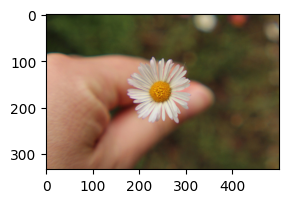

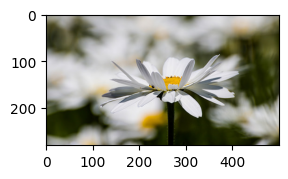

In [ ]:
# 샘플 이미지 출력하기
for img_file in daisy_list[:2]:
    img = Image.open(daisy_path + img_file)
    plt.figure(figsize=(3, 3)) # Set a smaller figure size
    plt.imshow(img)
    plt.show()

## 2. 이미지 라벨링 및 이미지 리스트 만들기

In [ ]:
class2idx = {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}
idx2class = {0: 'daisy', 1: 'dandelion', 2: 'roses', 3: 'sunflowers', 4: 'tulips'}

In [ ]:
# 이미지 리스트 및 라벨 리스트 만들기
img_list = []
label_list = []

for img_file in daisy_list:
    img = Image.open(daisy_path + img_file).resize((128, 128))
    img = np.array(img)/255. # 이미지 스케일링
    img_list.append(img)
    label_list.append(class2idx['daisy'])

for img_file in dandelion_list:
    img = Image.open(dandelion_path + img_file).resize((128, 128))
    img = np.array(img)/255.
    img_list.append(img)
    label_list.append(class2idx['dandelion'])

for img_file in roses_list:
    img = Image.open(roses_path + img_file).resize((128, 128))
    img = np.array(img)/255.
    img_list.append(img)
    label_list.append(class2idx['roses'])

for img_file in sunflowers_list:
    img = Image.open(sunflowers_path + img_file).resize((128, 128))
    img = np.array(img)/255.
    img_list.append(img)
    label_list.append(class2idx['sunflowers'])

for img_file in tulips_list:
    img = Image.open(tulips_path + img_file).resize((128, 128))
    img = np.array(img)/255.
    img_list.append(img)
    label_list.append(class2idx['tulips'])


In [ ]:
# img_list에 있는 이미지들의 크기(size) 확인

print(f"Total number of images in img_list: {len(img_list)}")
print("Sizes of the first 5 images:")
for i, img in enumerate(img_list[:1]):
    print(f"  Image {i+1} size: {img.shape}")

Total number of images in img_list: 3670
Sizes of the first 5 images:
  Image 1 size: (128, 128, 3)


In [ ]:
# 이미지 리스트 및 라벨 리스트를 numpy arrray로 변경
img_list_arr = np.array(img_list)
label_list_arr = np.array(label_list)

In [ ]:
# 이미지 array와 라벨 array shape 확인
print(f"Image array shape: {img_list_arr.shape}")
print(f"Label array shape: {label_list_arr.shape}")

Image array shape: (3670, 128, 128, 3)
Label array shape: (3670,)


## Train / Test / Validation 데이터셋 만들기

In [ ]:
# Train, Validation, Test 데이터셋 만들기 (7:2:1)
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(img_list_arr, label_list_arr, test_size=0.2, random_state=42)

# test 데이터가 있는 경우 제거
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.5, random_state=42)

In [ ]:
# train 및 val 데이터셋 shape 확인
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

X_train shape: (2936, 128, 128, 3)
y_train shape: (2936,)
X_val shape: (367, 128, 128, 3)
y_val shape: (367,)


## 3. Build Model

### 3.1 Sequential Model

In [ ]:
# Hyperparameter Tunning

num_epochs = 10 # origin 10
batch_size = 32

learning_rate = 0.001
dropout_rate = 0.5

input_shape = (128, 128, 3)  # 사이즈 확인

In [ ]:
# Sequential 모델 정의
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D

model = Sequential()
model.add(Conv2D(32, kernel_size=(5,5), strides=(1,1), padding='same', activation='relu', input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Conv2D(64,(2,2), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(5, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 모델 컴파일
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate),  # Optimization
              loss='sparse_categorical_crossentropy',  # Loss Function
              metrics=['accuracy'])  # Metrics / Accuracy

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,400,069 (32.04 MB)

 Trainable params: 8,400,069 (32.04 MB)

 Non-trainable params: 0 (0.00 B)

### Callback

In [ ]:
# callback : EarlyStopping, ModelCheckpoint

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# EarlyStopping
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5)

# ModelCheckpoint
checkpoint_path = "my_checkpoint.keras"
checkpoint = ModelCheckpoint(filepath=checkpoint_path,
                             save_best_only=True,
                             monitor='val_loss',
                             verbose=1)

### 3.2 모델 학습

In [ ]:
history = model.fit(X_train, y_train, batch_size=batch_size, epochs=num_epochs, validation_data=(X_val, y_val), callbacks=[es, checkpoint])

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.3509 - loss: 1.8545
Epoch 1: val_loss improved from None to 1.20563, saving model to my_checkpoint.keras

Epoch 1: finished saving model to my_checkpoint.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - accuracy: 0.4414 - loss: 1.4446 - val_accuracy: 0.5204 - val_loss: 1.2056
Epoch 2/10
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5730 - loss: 1.0990
Epoch 2: val_loss improved from 1.20563 to 1.00245, saving model to my_checkpoint.keras

Epoch 2: finished saving model to my_checkpoint.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5821 - loss: 1.0617 - val_accuracy: 0.5695 - val_loss: 1.0025
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6679 - loss: 0.8923
Epoch 3: val_loss improved from 1.00245 to 0.98152, saving model to my_checkpoint.keras

Epoch 3: finished saving model to my_checkpoint.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6717 - loss: 0.8825 - val_accura

In [ ]:
PHONE_NUMBER = "01030101825"
MODEL_FILENAME_1 = f"{PHONE_NUMBER}_1.h5"  # Keras 모델은 .keras 또는 .h5 권장
# MODEL_FILENAME_1 = f"{PHONE_NUMBER}_1.pkl"  # Scikit-learn 모델은 .pkl 또는 .joblib 권장
CSV_FILENAME_1 = f"{PHONE_NUMBER}_1.csv"

In [ ]:
model.save(MODEL_FILENAME_1)
print(f"Model saved to {MODEL_FILENAME_1}")

Model saved to 01030101825_1.h5


## 테스트 데이터셋 예측 및 결과 저장

모델 예측 결과와 함께 원본 이미지 파일명을 저장하기 위해 데이터셋을 다시 로드하고 분할해야 합니다. 기존 `train_test_split` 과정에서는 파일명이 추적되지 않았기 때문입니다.

In [ ]:
# 모든 이미지 경로와 라벨 다시 수집
all_image_paths_full = []
all_labels_numerical_recreated = []

# 꽃 종류 디렉토리 리스트
flower_types = ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']

for flower_type in flower_types:
    current_path = str(data_dir / flower_type) + '/'
    current_list = os.listdir(current_path)
    for img_file in current_list:
        all_image_paths_full.append(current_path + img_file)
        all_labels_numerical_recreated.append(class2idx[flower_type])

print(f"총 이미지 수 (재수집): {len(all_image_paths_full)}")
print(f"총 라벨 수 (재수집): {len(all_labels_numerical_recreated)}")

총 이미지 수 (재수집): 3670
총 라벨 수 (재수집): 3670


In [ ]:
# 이미지 로드 및 전처리 (다시)
all_image_arrays_recreated = []
for img_path in all_image_paths_full:
    img = Image.open(img_path).resize((128, 128))
    img = np.array(img) / 255.
    all_image_arrays_recreated.append(img)

all_image_arrays_recreated = np.array(all_image_arrays_recreated)
all_labels_numerical_recreated = np.array(all_labels_numerical_recreated)

print(f"재구성된 이미지 배열 shape: {all_image_arrays_recreated.shape}")
print(f"재구성된 라벨 배열 shape: {all_labels_numerical_recreated.shape}")

재구성된 이미지 배열 shape: (3670, 128, 128, 3)
재구성된 라벨 배열 shape: (3670,)


In [ ]:
# 이미지 배열, 라벨, 파일 경로를 함께 분할
from sklearn.model_selection import train_test_split

# Combine images, labels, and paths into a single list of tuples
combined_data = list(zip(all_image_arrays_recreated, all_labels_numerical_recreated, all_image_paths_full))

# First split: train and (validation + test)
train_data, val_test_data = train_test_split(combined_data, test_size=0.2, random_state=42)

# Second split: validation and test
val_data, test_data = train_test_split(val_test_data, test_size=0.5, random_state=42)

# Unpack test_data
X_test_new, y_test_new, paths_test_new = zip(*test_data)
X_test_new = np.array(X_test_new)
y_test_new = np.array(y_test_new)
paths_test_new = np.array(paths_test_new)

print(f"X_test_new shape: {X_test_new.shape}")
print(f"y_test_new shape: {y_test_new.shape}")
print(f"Test paths count: {len(paths_test_new)}")

X_test_new shape: (367, 128, 128, 3)
y_test_new shape: (367,)
Test paths count: 367


In [ ]:
# 저장된 모델 로드 (최적 성능 모델)
from tensorflow.keras.models import load_model

best_model = load_model(checkpoint_path)
print(f"Model loaded from {checkpoint_path}")

Model loaded from my_checkpoint.keras


In [ ]:
# 테스트 데이터셋으로 예측 수행
predictions = best_model.predict(X_test_new)
predicted_labels_numerical = np.argmax(predictions, axis=1)

print(f"예측된 라벨 개수: {len(predicted_labels_numerical)}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
예측된 라벨 개수: 367


In [ ]:
# 숫자 라벨을 클래스 이름으로 변환
y_test_names = [idx2class[label] for label in y_test_new]
predicted_names = [idx2class[label] for label in predicted_labels_numerical]

# 결과를 데이터프레임으로 생성
import pandas as pd

results_df = pd.DataFrame({
    'Image_Path': paths_test_new,
    'True_Label': y_test_names,
    'Predicted_Label': predicted_names
})

# 결과 미리보기
display(results_df.head())

,Image_Path,True_Label,Predicted_Label
0,/root/.keras/datasets/flower_photos/flower_pho...,sunflowers,tulips
1,/root/.keras/datasets/flower_photos/flower_pho...,tulips,tulips
2,/root/.keras/datasets/flower_photos/flower_pho...,tulips,tulips
3,/root/.keras/datasets/flower_photos/flower_pho...,tulips,roses
4,/root/.keras/datasets/flower_photos/flower_pho...,dandelion,dandelion


In [ ]:
# 결과를 CSV 파일로 저장
results_df.to_csv(CSV_FILENAME_1, index=False, encoding='utf-8')

print(f"예측 결과가 '{CSV_FILENAME_1}' 파일로 저장되었습니다.")

예측 결과가 '01030101825_1.csv' 파일로 저장되었습니다.


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_new, predicted_labels_numerical)
print(f"테스트 데이터셋 예측 정확도: {accuracy:.4f}")

테스트 데이터셋 예측 정확도: 0.6403


## 모델 정확도 향상을 위한 수정

모델의 성능을 개선하기 위해 다음을 수행합니다:

1.  **데이터 증강(Data Augmentation) 추가**: 이미지 데이터를 무작위로 변형하여 모델이 다양한 이미지에 더 잘 일반화되도록 합니다.
2.  **배치 정규화(Batch Normalization) 추가**: 각 계층의 출력을 정규화하여 학습 과정을 안정화하고 속도를 높입니다.
3.  **에폭(Epoch) 및 Early Stopping Patience 증가**: 모델이 더 오랫동안 학습하고 최적의 가중치를 찾을 수 있도록 합니다.

In [ ]:
# Hyperparameter Tunning (num_epochs 증가)

num_epochs = 50 # 이전 10에서 증가
batch_size = 32

learning_rate = 0.001
dropout_rate = 0.5

input_shape = (128, 128, 3)

In [ ]:
# EarlyStopping patience 증가

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# EarlyStopping
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10) # 이전 5에서 증가

# ModelCheckpoint
checkpoint_path = "my_checkpoint_improved.keras" # 새로운 체크포인트 경로
checkpoint = ModelCheckpoint(filepath=checkpoint_path,
                             save_best_only=True,
                             monitor='val_loss',
                             verbose=1)

In [ ]:
# Sequential 모델 정의 (Data Augmentation 및 BatchNormalization 추가)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras import layers

model_improved = Sequential([
    # Data Augmentation Layers (강도 약화)
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1), # 0.2 -> 0.1로 감소
    layers.RandomZoom(0.1),    # 0.2 -> 0.1로 감소

    # First Conv Block
    Conv2D(32, kernel_size=(5,5), strides=(1,1), padding='same', activation='relu', input_shape=input_shape),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2), strides=(2,2)),

    # Second Conv Block
    Conv2D(64,(2,2), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.2),

    # Dense Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(5, activation='softmax')
])

# 모델 컴파일
model_improved.compile(optimizer=tf.keras.optimizers.Adam(learning_rate),
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

model_improved.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_improved = model_improved.fit(X_train, y_train, batch_size=batch_size, epochs=num_epochs, validation_data=(X_val, y_val), callbacks=[es, checkpoint])

Epoch 1/50
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3960 - loss: 1.4110
Epoch 1: val_loss did not improve from 0.99422
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.3900 - loss: 1.4133 - val_accuracy: 0.3597 - val_loss: 1.4773
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3594 - loss: 1.4043
Epoch 2: val_loss did not improve from 0.99422
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.3740 - loss: 1.3835 - val_accuracy: 0.3161 - val_loss: 1.4263
Epoch 3/50
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3771 - loss: 1.4214
Epoch 3: val_loss did not improve from 0.99422
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.3692 - loss: 1.4050 - val_accuracy: 0.4033 - val_loss: 1.3620
Epoch 4/50
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3984 - loss: 1.3498
Epoch 4: val_loss did not improve from 0.99422
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.4009 - loss: 1.3499 - val_accuracy: 0.4578 - val_loss: 1.3253
Epoch 5/

In [ ]:
model_improved.save(f"model_improved_{PHONE_NUMBER}.h5")
print(f"Improved model saved to model_improved_{PHONE_NUMBER}.h5")

Improved model saved to model_improved_01030101825.h5


In [ ]:
from tensorflow.keras.models import load_model

best_improved_model = load_model(checkpoint_path)
print(f"Improved model loaded from {checkpoint_path}")

Improved model loaded from my_checkpoint_improved.keras


In [ ]:
predictions_improved = best_improved_model.predict(X_test_new)
predicted_labels_numerical_improved = np.argmax(predictions_improved, axis=1)

print(f"개선된 모델 예측된 라벨 개수: {len(predicted_labels_numerical_improved)}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
개선된 모델 예측된 라벨 개수: 367


In [ ]:
from sklearn.metrics import accuracy_score

accuracy_improved = accuracy_score(y_test_new, predicted_labels_numerical_improved)
print(f"개선된 모델 테스트 데이터셋 예측 정확도: {accuracy_improved:.4f}")

개선된 모델 테스트 데이터셋 예측 정확도: 0.6213


In [ ]:
# 숫자 라벨을 클래스 이름으로 변환 (개선된 모델 결과)
y_test_names_improved = [idx2class[label] for label in y_test_new]
predicted_names_improved = [idx2class[label] for label in predicted_labels_numerical_improved]

# 개선된 모델 결과를 데이터프레임으로 생성
import pandas as pd

results_df_improved = pd.DataFrame({
    'Image_Path': paths_test_new,
    'True_Label': y_test_names_improved,
    'Predicted_Label_Improved': predicted_names_improved
})

# 개선된 결과 미리보기
display(results_df_improved.head())

,Image_Path,True_Label,Predicted_Label_Improved
0,/root/.keras/datasets/flower_photos/flower_pho...,sunflowers,sunflowers
1,/root/.keras/datasets/flower_photos/flower_pho...,tulips,sunflowers
2,/root/.keras/datasets/flower_photos/flower_pho...,tulips,tulips
3,/root/.keras/datasets/flower_photos/flower_pho...,tulips,sunflowers
4,/root/.keras/datasets/flower_photos/flower_pho...,dandelion,dandelion


In [ ]:
CSV_FILENAME_IMPROVED = f"{PHONE_NUMBER}_1_improved.csv"
results_df_improved.to_csv(CSV_FILENAME_IMPROVED, index=False, encoding='utf-8')

print(f"개선된 예측 결과가 '{CSV_FILENAME_IMPROVED}' 파일로 저장되었습니다.")

개선된 예측 결과가 '01030101825_1_improved.csv' 파일로 저장되었습니다.


In [ ]:
# 개선된 모델 학습
history_improved = model_improved.fit(X_train, y_train, batch_size=batch_size, epochs=num_epochs, validation_data=(X_val, y_val), callbacks=[es, checkpoint])

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3329 - loss: 6.8369
Epoch 1: val_loss did not improve from 0.99422
92/92 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.3236 - loss: 3.3682 - val_accuracy: 0.3243 - val_loss: 12.5421
Epoch 2/50
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.2952 - loss: 1.5620
Epoch 2: val_loss did not improve from 0.99422
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.3065 - loss: 1.5255 - val_accuracy: 0.2943 - val_loss: 15.7954
Epoch 3/50
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3250 - loss: 1.5113
Epoch 3: val_loss did not improve from 0.99422
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.3096 - loss: 1.5112 - val_accuracy: 0.2943 - val_loss: 20.3477
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3340 - loss: 1.4489
Epoch 4: val_loss did not improve from 0.99422
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - accuracy: 0.3266 - loss: 1.4566 - val_accuracy: 0.3243 - val_loss: 13.1091
Epoc

In [ ]:
# 개선된 모델 저장
model_improved.save(f"model_improved_{PHONE_NUMBER}.h5")
print(f"Improved model saved to model_improved_{PHONE_NUMBER}.h5")

Improved model saved to model_improved_01030101825.h5


In [ ]:
# 저장된 개선된 모델 로드 (최적 성능 모델)
from tensorflow.keras.models import load_model

best_improved_model = load_model(checkpoint_path)
print(f"Improved model loaded from {checkpoint_path}")

Improved model loaded from my_checkpoint_improved.keras


In [ ]:
# 개선된 모델로 테스트 데이터셋으로 예측 수행
predictions_improved = best_improved_model.predict(X_test_new)
predicted_labels_numerical_improved = np.argmax(predictions_improved, axis=1)

print(f"개선된 모델 예측된 라벨 개수: {len(predicted_labels_numerical_improved)}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
개선된 모델 예측된 라벨 개수: 367


In [ ]:
# 개선된 모델의 예측 정확도 계산
from sklearn.metrics import accuracy_score

accuracy_improved = accuracy_score(y_test_new, predicted_labels_numerical_improved)
print(f"개선된 모델 테스트 데이터셋 예측 정확도: {accuracy_improved:.4f}")

개선된 모델 테스트 데이터셋 예측 정확도: 0.6213


In [ ]:
# 숫자 라벨을 클래스 이름으로 변환 (개선된 모델 결과)
y_test_names_improved = [idx2class[label] for label in y_test_new]
predicted_names_improved = [idx2class[label] for label in predicted_labels_numerical_improved]

# 개선된 모델 결과를 데이터프레임으로 생성
import pandas as pd

results_df_improved = pd.DataFrame({
    'Image_Path': paths_test_new,
    'True_Label': y_test_names_improved,
    'Predicted_Label_Improved': predicted_names_improved
})

# 개선된 결과 미리보기
display(results_df_improved.head())

,Image_Path,True_Label,Predicted_Label_Improved
0,/root/.keras/datasets/flower_photos/flower_pho...,sunflowers,sunflowers
1,/root/.keras/datasets/flower_photos/flower_pho...,tulips,sunflowers
2,/root/.keras/datasets/flower_photos/flower_pho...,tulips,tulips
3,/root/.keras/datasets/flower_photos/flower_pho...,tulips,sunflowers
4,/root/.keras/datasets/flower_photos/flower_pho...,dandelion,dandelion


In [ ]:
# 개선된 결과를 CSV 파일로 저장
CSV_FILENAME_IMPROVED = f"{PHONE_NUMBER}_1_improved.csv"
results_df_improved.to_csv(CSV_FILENAME_IMPROVED, index=False, encoding='utf-8')

print(f"개선된 예측 결과가 '{CSV_FILENAME_IMPROVED}' 파일로 저장되었습니다.")

개선된 예측 결과가 '01030101825_1_improved.csv' 파일로 저장되었습니다.


In [ ]:
# 개선된 모델 학습
history_improved = model_improved.fit(X_train, y_train, batch_size=batch_size, epochs=num_epochs, validation_data=(X_val, y_val), callbacks=[es, checkpoint])

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3192 - loss: 8.4142
Epoch 1: val_loss improved from None to 17.56602, saving model to my_checkpoint_improved.keras

Epoch 1: finished saving model to my_checkpoint_improved.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 0.3113 - loss: 4.0668 - val_accuracy: 0.2071 - val_loss: 17.5660
Epoch 2/50
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3027 - loss: 1.5263
Epoch 2: val_loss did not improve from 17.56602
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.3229 - loss: 1.5193 - val_accuracy: 0.2371 - val_loss: 22.7467
Epoch 3/50
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3522 - loss: 1.4623
Epoch 3: val_loss improved from 17.56602 to 17.54042, saving model to my_checkpoint_improved.keras

Epoch 3: finished saving model to my_checkpoint_improved.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.3593 - loss: 1.4649 - val_accuracy: 0.2371 - val_loss: 17.5404
Epoch 4/50
91/92 ━━━━━━

In [ ]:
# 개선된 모델 저장
model_improved.save(f"model_improved_{PHONE_NUMBER}.h5")
print(f"Improved model saved to model_improved_{PHONE_NUMBER}.h5")

Improved model saved to model_improved_01030101825.h5


In [ ]:
# 저장된 개선된 모델 로드 (최적 성능 모델)
from tensorflow.keras.models import load_model

best_improved_model = load_model(checkpoint_path)
print(f"Improved model loaded from {checkpoint_path}")

Improved model loaded from my_checkpoint_improved.keras


In [ ]:
# 개선된 모델로 테스트 데이터셋으로 예측 수행
predictions_improved = best_improved_model.predict(X_test_new)
predicted_labels_numerical_improved = np.argmax(predictions_improved, axis=1)

print(f"개선된 모델 예측된 라벨 개수: {len(predicted_labels_numerical_improved)}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
개선된 모델 예측된 라벨 개수: 367


In [ ]:
# 개선된 모델의 예측 정확도 계산
from sklearn.metrics import accuracy_score

accuracy_improved = accuracy_score(y_test_new, predicted_labels_numerical_improved)
print(f"개선된 모델 테스트 데이터셋 예측 정확도: {accuracy_improved:.4f}")

개선된 모델 테스트 데이터셋 예측 정확도: 0.6213


In [ ]:
# 숫자 라벨을 클래스 이름으로 변환 (개선된 모델 결과)
y_test_names_improved = [idx2class[label] for label in y_test_new]
predicted_names_improved = [idx2class[label] for label in predicted_labels_numerical_improved]

# 개선된 모델 결과를 데이터프레임으로 생성
import pandas as pd

results_df_improved = pd.DataFrame({
    'Image_Path': paths_test_new,
    'True_Label': y_test_names_improved,
    'Predicted_Label_Improved': predicted_names_improved
})

# 개선된 결과 미리보기
display(results_df_improved.head())

,Image_Path,True_Label,Predicted_Label_Improved
0,/root/.keras/datasets/flower_photos/flower_pho...,sunflowers,sunflowers
1,/root/.keras/datasets/flower_photos/flower_pho...,tulips,sunflowers
2,/root/.keras/datasets/flower_photos/flower_pho...,tulips,tulips
3,/root/.keras/datasets/flower_photos/flower_pho...,tulips,sunflowers
4,/root/.keras/datasets/flower_photos/flower_pho...,dandelion,dandelion


In [ ]:
# 개선된 결과를 CSV 파일로 저장
CSV_FILENAME_IMPROVED = f"{PHONE_NUMBER}_1_improved.csv"
results_df_improved.to_csv(CSV_FILENAME_IMPROVED, index=False, encoding='utf-8')

print(f"개선된 예측 결과가 '{CSV_FILENAME_IMPROVED}' 파일로 저장되었습니다.")

개선된 예측 결과가 '01030101825_1_improved.csv' 파일로 저장되었습니다.


```markdown
## 학습 곡선 시각화 (개선된 모델)

모델의 학습 과정에서 훈련 세트와 검증 세트의 손실 및 정확도 변화를 시각화하여 성능 저하의 원인을 분석합니다.
```

개선된 모델의 학습 곡선:


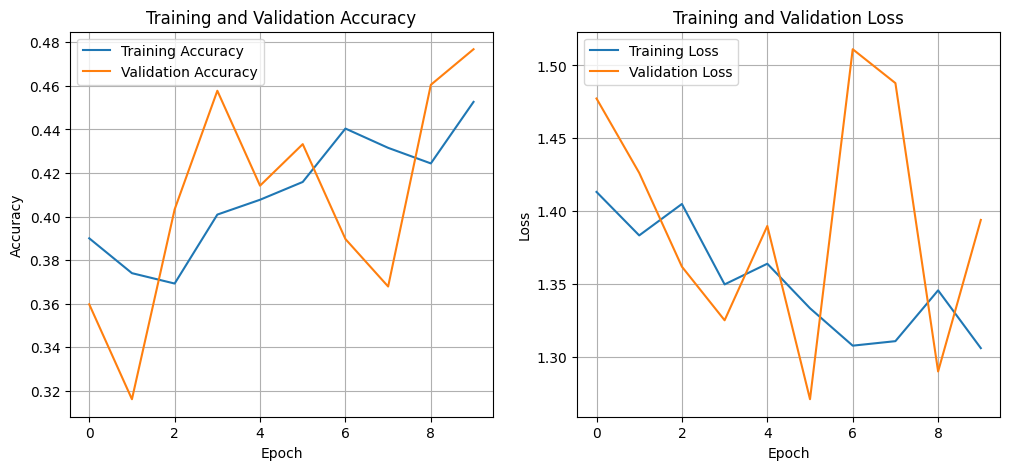

In [ ]:
import matplotlib.pyplot as plt

def plot_learning_curves(history):
    # 정확도 그래프
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # 손실 그래프
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

# 개선된 모델의 학습 곡선 시각화
print("개선된 모델의 학습 곡선:")
plot_learning_curves(history_improved)

## 4. 전이 학습 (Transfer Learning)

전이 학습은 이미 대규모 데이터셋(예: ImageNet)으로 학습된 모델의 가중치를 가져와 새로운 유사한 태스크에 활용하는 기법입니다. 이를 통해 적은 양의 데이터로도 좋은 성능을 달성하고, 학습 시간을 단축하며, 과적합을 줄일 수 있습니다.

여기서는 MobileNetV2 모델을 사용하여 특징 추출기(feature extractor)로 활용하고, 그 위에 새로운 분류 층(classification layer)을 추가하여 꽃 이미지 분류 작업을 수행하겠습니다.


In [ ]:
# 필요한 라이브러리 임포트
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# MobileNetV2 기본 모델 로드 (ImageNet 가중치 사용, 최상위 분류 층 제외)
base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')

# 기본 모델의 가중치를 동결하여 훈련 중 업데이트되지 않도록 합니다.
base_model.trainable = False

# 기본 모델 위에 새로운 분류 층 추가
x = base_model.output
x = GlobalAveragePooling2D()(x) # 특징 맵을 단일 벡터로 변환
x = Dense(128, activation='relu')(x) # 새로운 완전 연결 층
x = Dropout(0.3)(x) # 과적합 방지를 위한 Dropout 추가
predictions = Dense(5, activation='softmax')(x) # 출력 층 (꽃 종류 5개)

# 새로운 모델 정의
model_transfer = Model(inputs=base_model.input, outputs=predictions)

# 모델 컴파일
model_transfer.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

model_transfer.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_71"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 모델 학습 (전이 학습)

동결된 `base_model`을 사용하여 새로운 분류 층만 학습시킵니다. `EarlyStopping`과 `ModelCheckpoint`를 사용하여 최적의 모델을 저장합니다.

In [ ]:
# ModelCheckpoint 경로 업데이트
checkpoint_path_transfer = "my_checkpoint_transfer.keras"
checkpoint_transfer = ModelCheckpoint(filepath=checkpoint_path_transfer,
                                      save_best_only=True,
                                      monitor='val_loss',
                                      verbose=1)

# 전이 학습 모델 학습
history_transfer = model_transfer.fit(X_train, y_train, batch_size=batch_size, epochs=num_epochs, validation_data=(X_val, y_val), callbacks=[es, checkpoint_transfer])

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.6090 - loss: 1.0972
Epoch 1: val_loss improved from None to 0.48180, saving model to my_checkpoint_transfer.keras

Epoch 1: finished saving model to my_checkpoint_transfer.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 48s 320ms/step - accuracy: 0.7428 - loss: 0.7191 - val_accuracy: 0.8202 - val_loss: 0.4818
Epoch 2/50
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8685 - loss: 0.3871
Epoch 2: val_loss improved from 0.48180 to 0.40333, saving model to my_checkpoint_transfer.keras

Epoch 2: finished saving model to my_checkpoint_transfer.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8767 - loss: 0.3571 - val_accuracy: 0.8556 - val_loss: 0.4033
Epoch 3/50
88/92 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9209 - loss: 0.2379
Epoch 3: val_loss did not improve from 0.40333
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9094 - loss: 0.2525 - val_accuracy: 0.8420 - val_loss: 0.4349
Epoch 4/50
92/92 ━━━━━━━━━━━

### 전이 학습 모델 평가

학습된 전이 학습 모델의 성능을 테스트 데이터셋으로 평가합니다.

In [ ]:
# 저장된 최적 전이 학습 모델 로드
best_model_transfer = load_model(checkpoint_path_transfer)
print(f"Transfer learning model loaded from {checkpoint_path_transfer}")

# 테스트 데이터셋으로 예측 수행
predictions_transfer = best_model_transfer.predict(X_test_new)
predicted_labels_numerical_transfer = np.argmax(predictions_transfer, axis=1)

# 예측 정확도 계산
accuracy_transfer = accuracy_score(y_test_new, predicted_labels_numerical_transfer)
print(f"전이 학습 모델 테스트 데이터셋 예측 정확도: {accuracy_transfer:.4f}")

# 예측 결과 저장
y_test_names_transfer = [idx2class[label] for label in y_test_new]
predicted_names_transfer = [idx2class[label] for label in predicted_labels_numerical_transfer]

results_df_transfer = pd.DataFrame({
    'Image_Path': paths_test_new,
    'True_Label': y_test_names_transfer,
    'Predicted_Label_Transfer': predicted_names_transfer
})

CSV_FILENAME_TRANSFER = f"{PHONE_NUMBER}_1_transfer.csv"
results_df_transfer.to_csv(CSV_FILENAME_TRANSFER, index=False, encoding='utf-8')

print(f"전이 학습 예측 결과가 '{CSV_FILENAME_TRANSFER}' 파일로 저장되었습니다.")
display(results_df_transfer.head())

Transfer learning model loaded from my_checkpoint_transfer.keras
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 391ms/step
전이 학습 모델 테스트 데이터셋 예측 정확도: 0.8801
전이 학습 예측 결과가 '01030101825_1_transfer.csv' 파일로 저장되었습니다.


,Image_Path,True_Label,Predicted_Label_Transfer
0,/root/.keras/datasets/flower_photos/flower_pho...,sunflowers,sunflowers
1,/root/.keras/datasets/flower_photos/flower_pho...,tulips,tulips
2,/root/.keras/datasets/flower_photos/flower_pho...,tulips,tulips
3,/root/.keras/datasets/flower_photos/flower_pho...,tulips,dandelion
4,/root/.keras/datasets/flower_photos/flower_pho...,dandelion,dandelion


### 전이 학습 모델 학습 곡선 시각화

전이 학습 모델의 학습 과정을 시각화하여 성능 변화를 분석합니다.

전이 학습 모델의 학습 곡선:


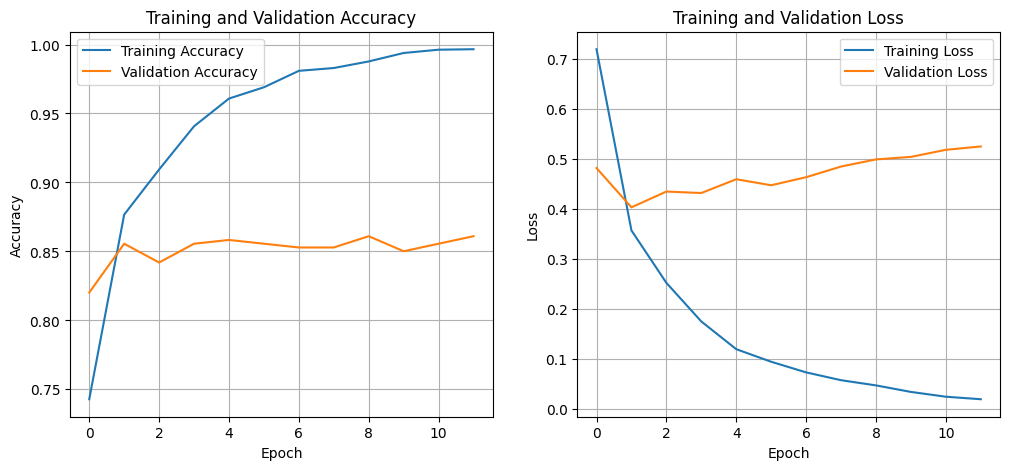

In [ ]:
print("전이 학습 모델의 학습 곡선:")
plot_learning_curves(history_transfer)